# Finding/opening ACCESS-OM3 `MC_25km_jra_ryf-1.0-beta` test run output using intake

This notebook demonstrates how to using intake-esm to find and load data data from the ACCESS-OM3 `MC_25km_jra_ryf-1.0-beta` test run.

For more information about using intake-esm to find and load data, see:
- the [intake-esm documentation](https://intake-esm.readthedocs.io/en/stable/)
- [this section](https://access-nri-intake-catalog.readthedocs.io/en/latest/usage/quickstart.html#using-an-intake-esm-datastore) of the access-nri-intake-catalog documentation

In [1]:
#The following cell must be in all notebooks!
#It allows us to run all the notebooks at once, note that the following cell has a tag "parameters" which allows us to pass in arguments externally using papermill (see mkfigs.sh for details)

In [2]:
#parameters

### USER EDIT start
esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json'
plotfolder='/g/data/tm70/ek4684/access-om3-paper-1/notebooks/mkfigs_output4/'
dpi=300
### USER EDIT stop

import matplotlib as mpl
import os
%matplotlib inline
mpl.rcParams['figure.dpi']= dpi

os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json
Plot folder path:  /g/data/tm70/ek4684/access-om3-paper-1/notebooks/mkfigs_output4/


In [3]:
import xarray as xr
import cf_xarray as cfxr
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client

In [4]:
client = Client(threads_per_worker=1)
print(client.dashboard_link)

/proxy/8787/status


2025-10-20 10:58:22,175 - distributed.scheduler - ERROR - Task 'finalize-hlgfinalizecompute-2d1a430b8351476db2d6c856bf2c1d97' has 3.68 GiB worth of input dependencies, but worker tcp://127.0.0.1:44109 has memory_limit set to 3.50 GiB. It seems like you called client.compute() on a huge collection. Consider writing to distributed storage or slicing/reducing first.
2025-10-20 10:59:12,602 - distributed.scheduler - ERROR - Task 'finalize-hlgfinalizecompute-9a7d71fe86284be59ed009abbf7a0cba' has 3.68 GiB worth of input dependencies, but worker tcp://127.0.0.1:40709 has memory_limit set to 3.50 GiB. It seems like you called client.compute() on a huge collection. Consider writing to distributed storage or slicing/reducing first.


### Open the intake-esm datastore

In [5]:
#datastore_path = "/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json"
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)


### What ocean variables are available at monthly frequency?

In [6]:
def available_variables(datastore):
    """Return a pandas dataframe summarising the variables in a datastore"""
    variable_columns = [col for col in datastore.df.columns if "variable" in col]
    return (
        datastore.df[variable_columns]
        .explode(variable_columns)
        .drop_duplicates()
        .set_index("variable")
        .sort_index()
    )

In [7]:
datastore_filtered = datastore.search(realm="ocean", frequency="1mon")

for col in COLUMNS_WITH_ITERABLES:
    datastore_filtered.df[col] = datastore_filtered.df[col].astype("object").map(lambda x: list(map(str, x)))

available_variables(datastore_filtered)

,variable_long_name,variable_standard_name,variable_cell_methods,variable_units
variable,,,,
Heat_PmE,Heat flux into ocean from mass flux into ocean,,area:mean yh:mean xh:mean time: mean,W m-2
KE,Layer kinetic energy per unit mass,,area:mean zl:mean yh:mean xh:mean time: mean,m2 s-2
Rd_dx,Ratio between deformation radius and grid spacing,,area:mean yh:mean xh:mean time: mean,m m-1
SSH,Sea Surface Height,,area:mean yh:mean xh:mean time: mean,m
SSU,Sea Surface Zonal Velocity,,yh:mean xq:point time: mean,m s-1
...,...,...,...,...
yh,h point nominal latitude,,,degrees_north
yq,q point nominal latitude,,,degrees_north
z_l,Depth at cell center,,,meters


In [8]:
df = available_variables(datastore_filtered)
print(df.index.to_list())

['Heat_PmE', 'KE', 'Rd_dx', 'SSH', 'SSU', 'SSV', 'T_adx_2d', 'T_ady_2d', 'T_diffx_2d', 'T_diffy_2d', 'agessc', 'agessc', 'average_DT', 'average_T1', 'average_T2', 'difmxybo', 'difmxylo', 'diftrblo', 'diftrelo', 'e', 'evs', 'ficeberg', 'friver', 'fsitherm', 'h', 'h', 'heat_added', 'heat_content_cond', 'heat_content_evap', 'heat_content_fprec', 'heat_content_frunoff', 'heat_content_lprec', 'heat_content_lrunoff', 'heat_content_vprec', 'hfds', 'hflso', 'hfsifrazil', 'hfsnthermds', 'hfsso', 'latent_evap', 'mass_wt', 'mlotst', 'net_heat_coupler', 'nv', 'opottempmint', 'prlq', 'prsn', 'pso', 'rhopot0', 'rhopot0', 'rlntds', 'rsntds', 'salt_flux_added', 'scalar_axis', 'seaice_melt_heat', 'sfdsi', 'soga', 'somint', 'sos', 'speed', 'tauuo', 'tauvo', 'thetaoga', 'time', 'time_bnds', 'tos', 'uh', 'uhGM', 'uhGM', 'uhbt', 'uhml', 'uhml', 'umo', 'umo', 'uo', 'uo', 'ustar', 'vh', 'vhGM', 'vhGM', 'vhbt', 'vhml', 'vhml', 'vmo', 'vmo', 'vo', 'vo', 'volcello', 'volcello', 'vprec', 'wfo', 'xh', 'xq', 'yh',

### Load monthly sea surface height (`zos`) and plot the field at the last available time

In [9]:
zos = datastore.search(variable="SSH", frequency="1mon").to_dask(
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [9]:
zos['SSH']

<xarray.DataArray 'SSH' (time: 600, yh: 1142, xh: 1440)> Size: 4GB
dask.array<concatenate, shape=(600, 1142, 1440), dtype=float32, chunksize=(12, 1142, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 5kB 1981-01-16T12:00:00 ... 2030-12-16T12:...
  * yh       (yh) float64 9kB -80.94 -80.87 -80.81 -80.74 ... 89.74 89.84 89.95
  * xh       (xh) float64 12kB -279.9 -279.6 -279.4 -279.1 ... 79.38 79.62 79.88
Attributes:
    units:          m
    long_name:      Sea Surface Height
    cell_methods:   area:mean yh:mean xh:mean time: mean
    cell_measures:  area: areacello
    time_avg_info:  average_T1,average_T2,average_DT

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/iris/coords.py:1982: IrisGuessBoundsWarning: Coordinate 'h point nominal longitude' is not bounded, guessing contiguous bounds.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/iris/coords.py:1982: IrisGuessBoundsWarning: Coordinate 'h point nominal latitude' is not bounded, guessing contiguous bounds.
  warnings.warn(


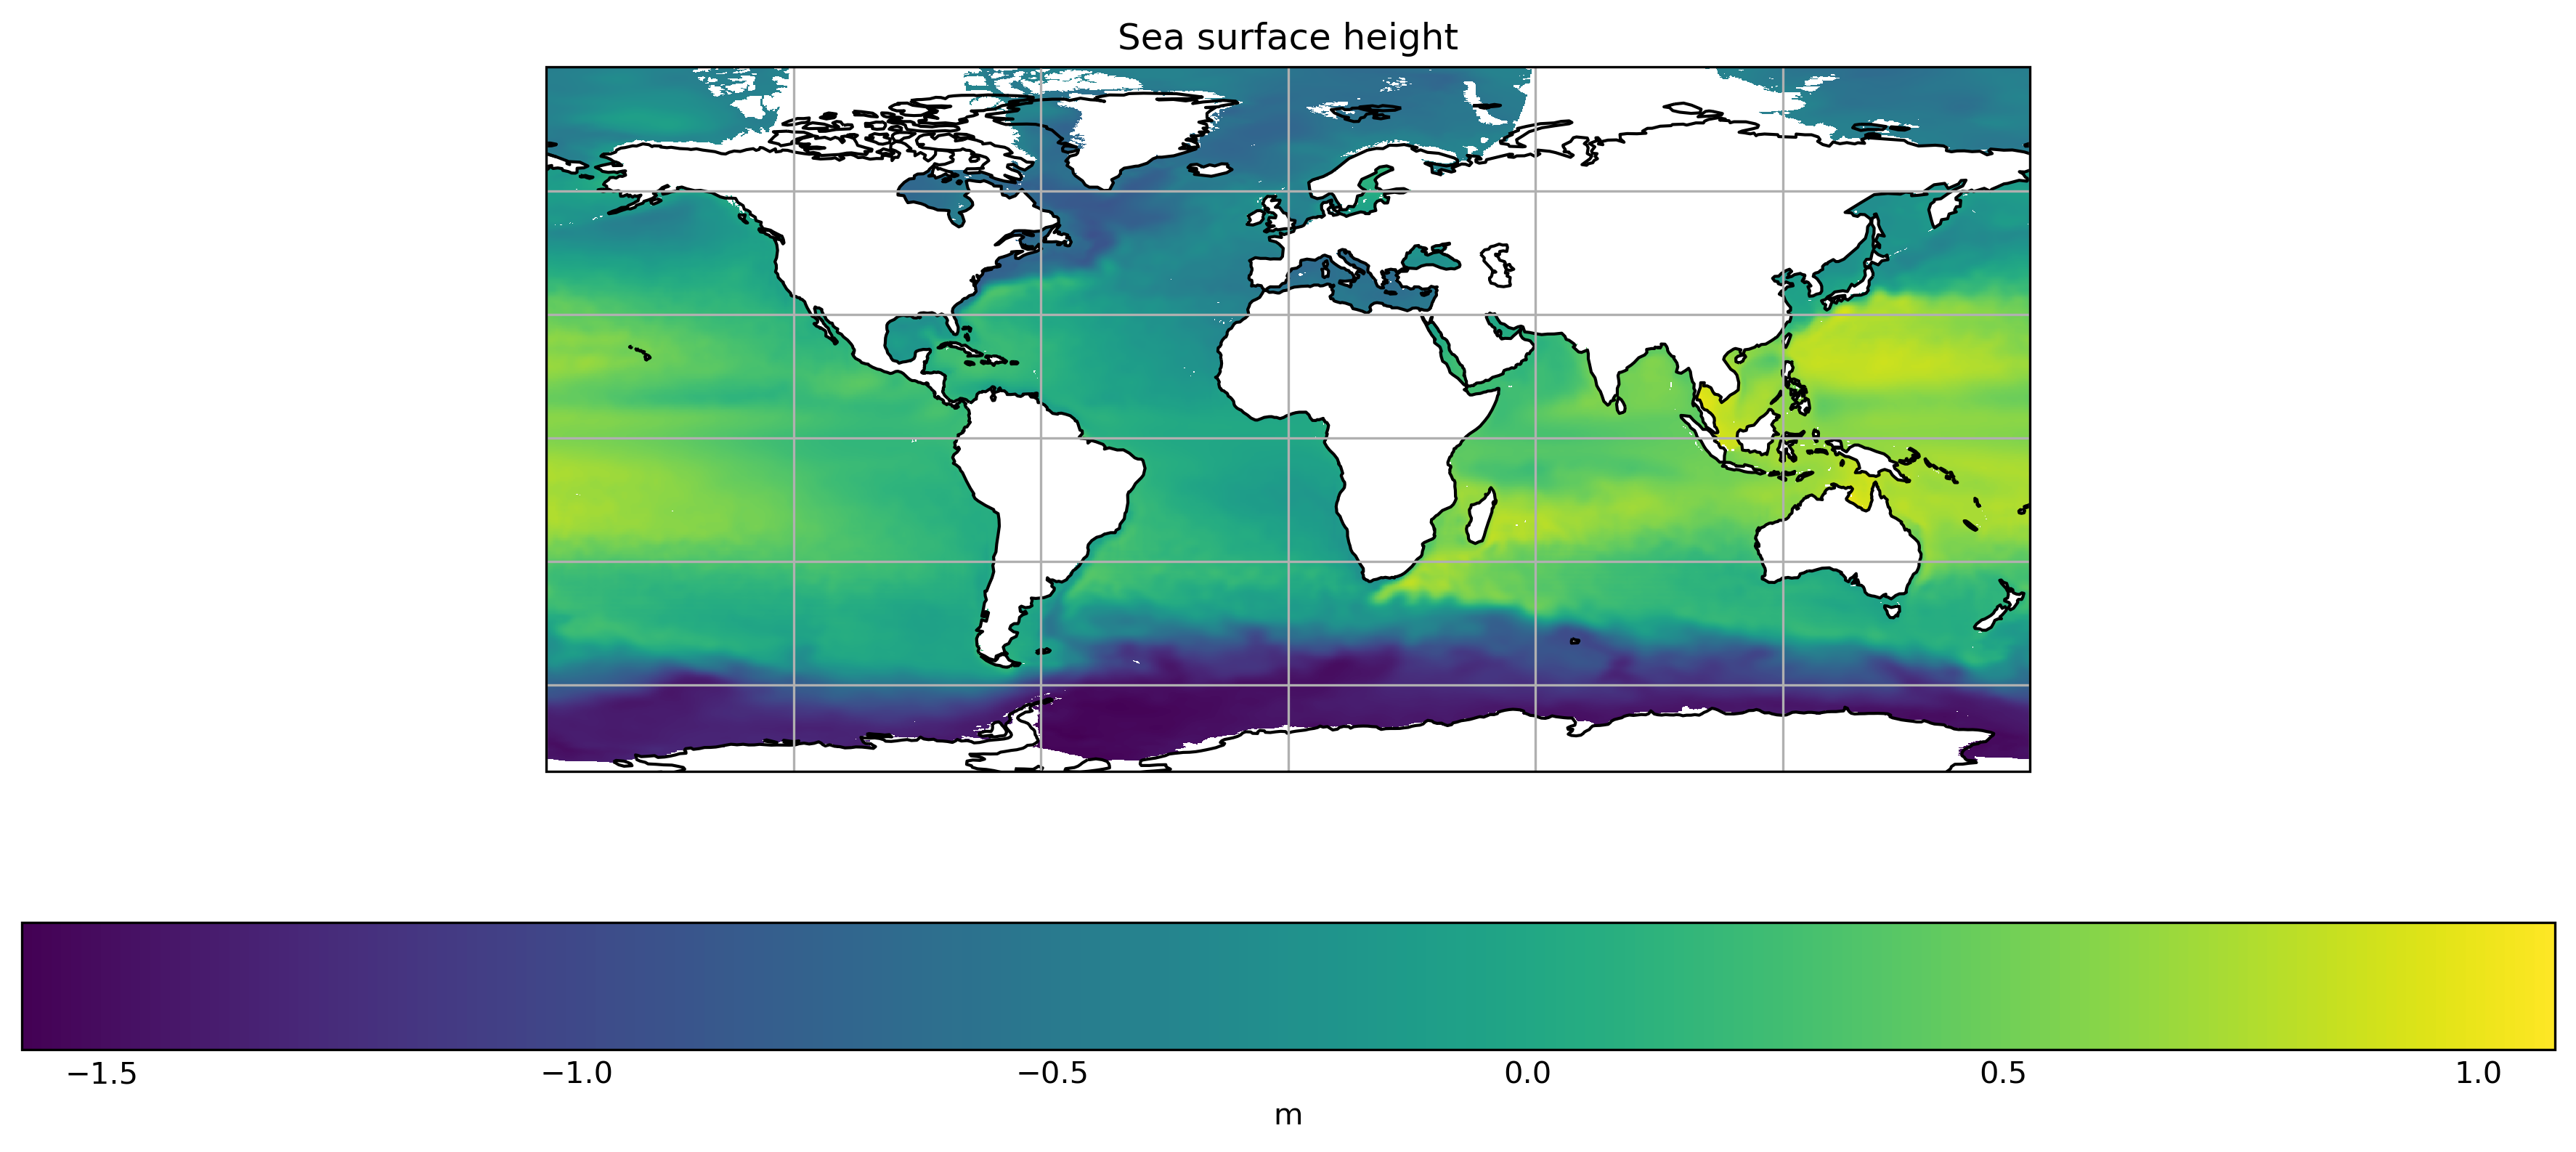

In [10]:
import iris
import iris.quickplot as qplt

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

icube = zos["SSH"].to_iris()

qplt.pcolormesh(icube[0], axes=ax)
ax.coastlines()
_ = ax.gridlines()

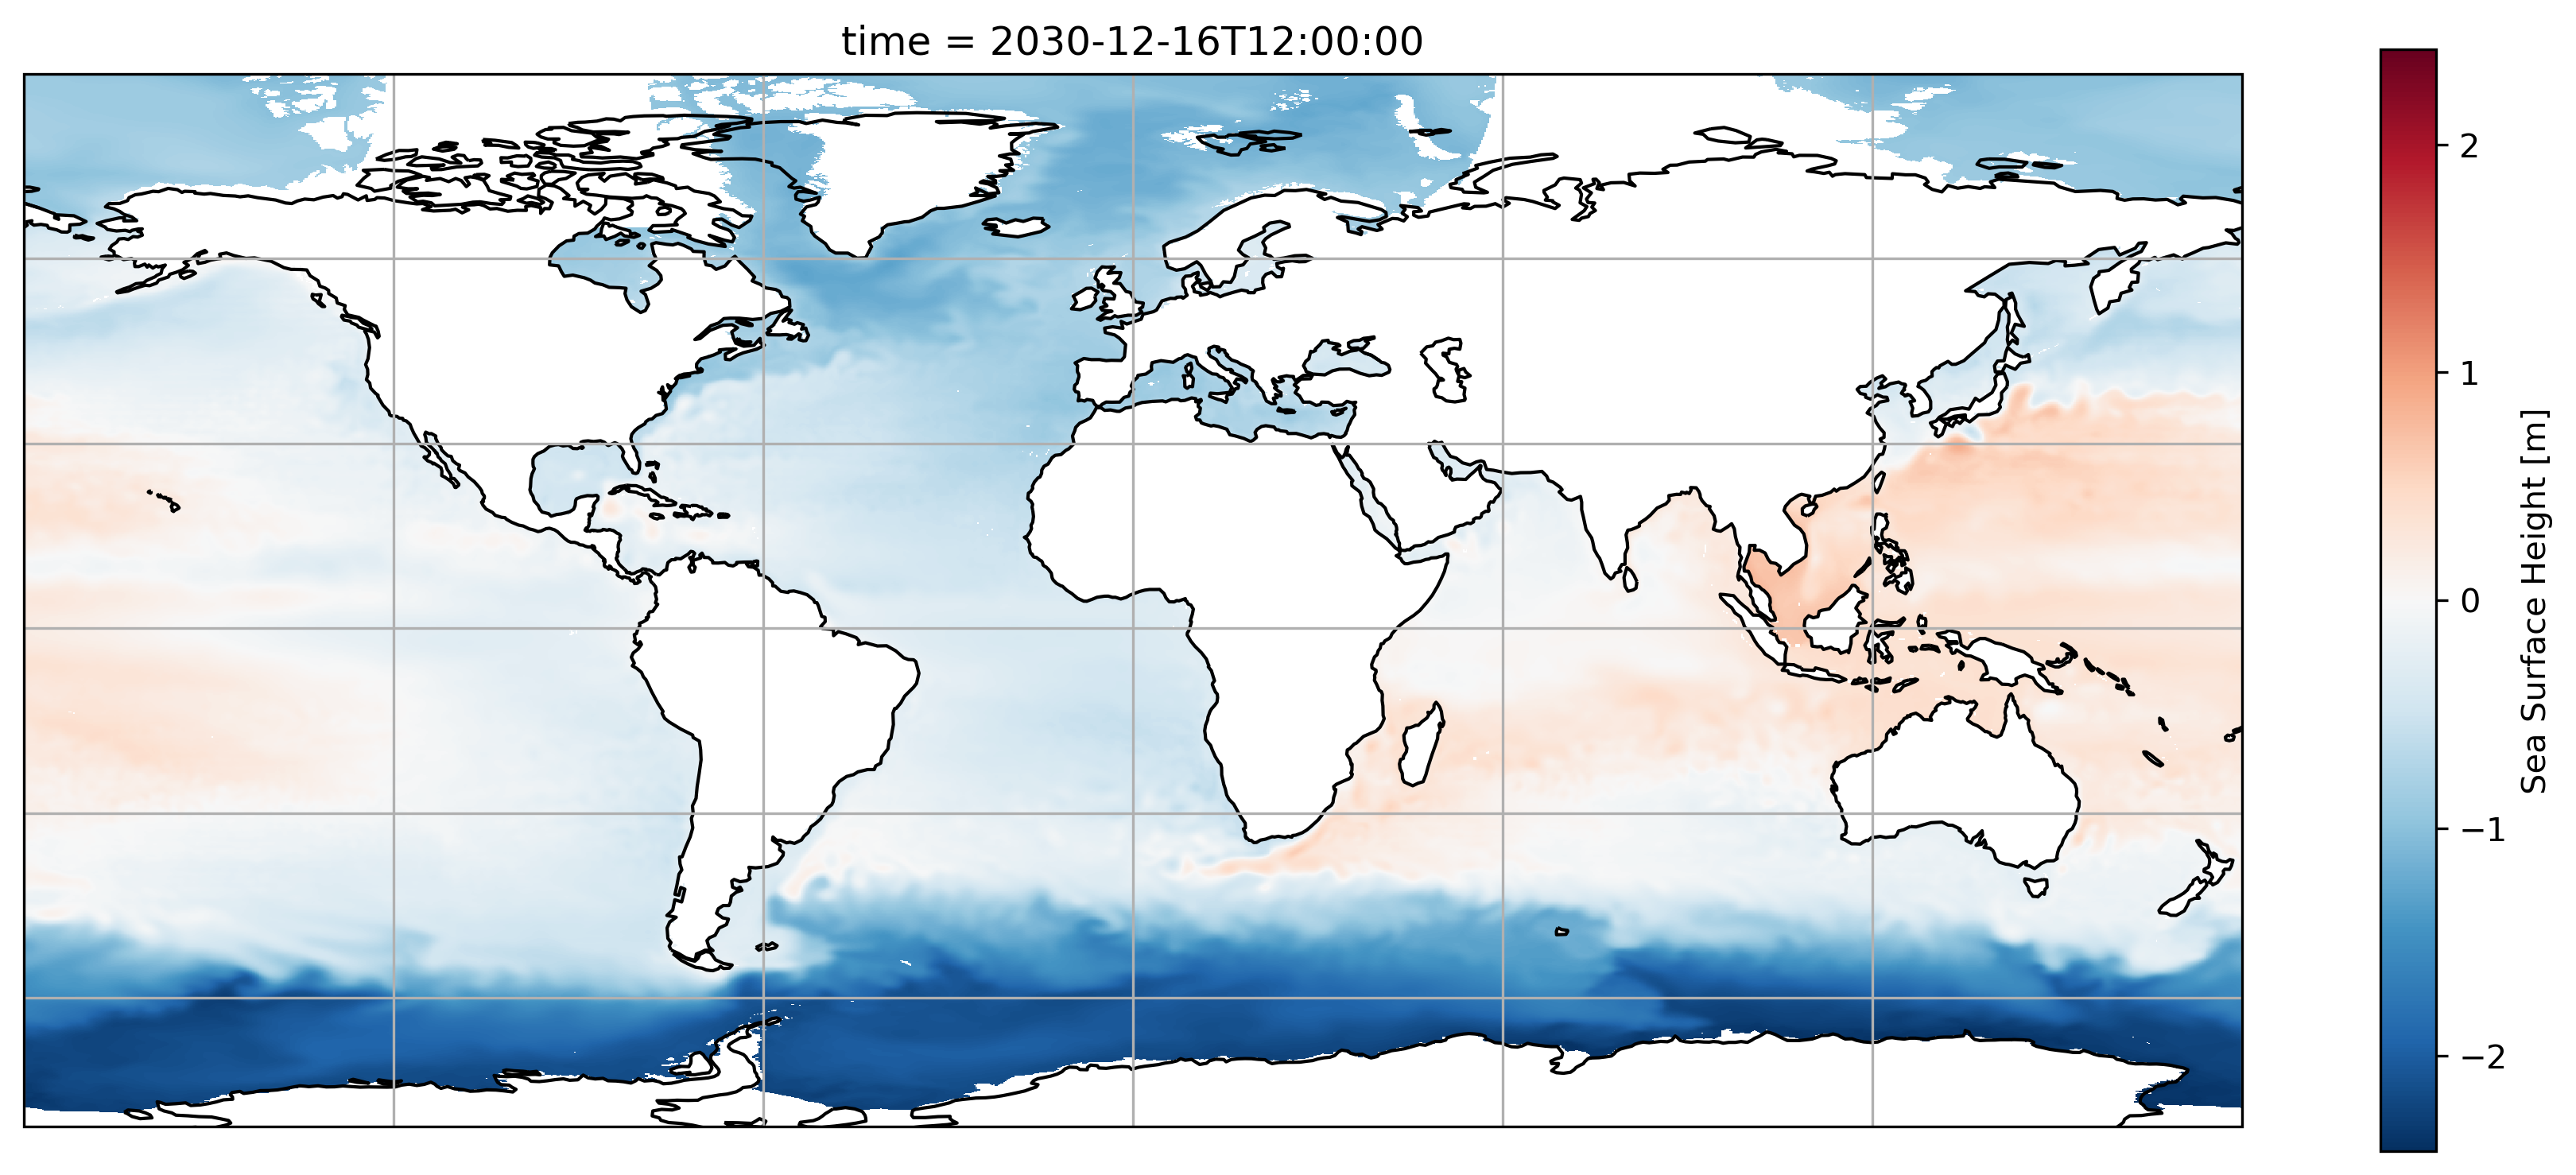

In [22]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

zos["SSH"].isel(time=-1).plot(ax=ax)
ax.coastlines()
_ = ax.gridlines()

#### Fixing the plot axes

Notice that the white land-masked regions are distorted away from the coastlines in the Arctic in the above plot. This is because a tripolar grid is used, so the grid lines are not zonal and meridional north of 65N, and consequently the nominal 1D coordinates `xh` and `yh` are incorrect. To fix this we need to use 2d coordinates `geolon` and `geolat`. We get these from a separate file which was generated without processor masking, avoiding regions on NaNs in the continents.


In [11]:
# get coords from short run without processor masking
# https://github.com/aekiss/MOM6-CICE6/commit/59ed8ffc6ae1d4a79821a951924e7c853d9b788a
# https://xgcm.readthedocs.io/en/latest/xgcm-examples/03_MOM6.html#A-note-on-geographical-coordinates
static = xr.open_dataset(r"/g/data/ik11/outputs/access-om3-025/grid/access-om3.mom6.static.nc")

coords = iris.load(r"/g/data/ik11/outputs/access-om3-025/grid/access-om3.mom6.static.nc", ['geolat', 'geolon'])

In [12]:
# coords[0]
# add aux coordinates
glat = iris.coords.AuxCoord(points=coords[0].data, standard_name='latitude', units=coords[0].units)
glon = iris.coords.AuxCoord(points=coords[1].data, standard_name='longitude', units=coords[1].units)
icube.add_aux_coord(glon, data_dims=[1,2])
icube.add_aux_coord(glat, data_dims=[1,2])

#use OceanFixGrid

In [13]:
for cb in iris.load(r"/g/data/ik11/outputs/access-om3-025/grid/access-om3.mom6.static.nc", 'Ocean Grid-Cell Area'):
    print(cb.standard_name, cb.var_name, cb.long_name)
# static
area = iris.load(r"/g/data/ik11/outputs/access-om3-025/grid/access-om3.mom6.static.nc",'cell_area')[0]
# iris.load(r"/g/data/ik11/outputs/access-om3-025/grid/access-om3.mom6.static.nc",'cell_area')
# static['areacello'].data

cell_area areacello_bu Ocean Grid-Cell Area
cell_area areacello_cu Ocean Grid-Cell Area
cell_area areacello_cv Ocean Grid-Cell Area


In [14]:
# also get areacello from this file
# coords[2]
cm_area = iris.coords.CellMeasure(area.data, var_name='areacello', units='m2', measure='area')
icube.add_cell_measure(cm_area, data_dims=[1,2])
icube

<iris 'Cube' of Sea Surface Height / (m) (time: 600; h point nominal latitude: 1142; h point nominal longitude: 1440)>

In [15]:
# use a function written in esmvalcore for irregular ocean grids on lat and lon with 2 dimensions
from esmvalcore.cmor._fixes.common import OceanFixGrid 
from esmvalcore.cmor.table import get_var_info

icube.var_name = 'zos' # use cmip variable name
var = OceanFixGrid(get_var_info('CMIP6','Omon','zos'))
cube = var.fix_metadata(cubes=iris.cube.CubeList([icube]))[0]
cube.coord('latitude').has_bounds(), cube.coords() 
# the fix add bounds to lat and lon but can maybe taken from elsewhere?

# other fixes.. 

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


(True,
 [<DimCoord: time / (days since 0001-01-01)  [1981-01-16 12:00:00, ...]  shape(600,)>,
  <DimCoord: cell index along second dimension / (1)  [0, ...]+bounds  shape(1142,)>,
  <DimCoord: cell index along first dimension / (1)  [ 0, 1, ..., 1438, 1439]+bounds  shape(1440,)>,
  <AuxCoord: latitude / (degrees)  [...]+bounds  shape(1142, 1440)>,
  <AuxCoord: longitude / (degrees)  [...]+bounds  shape(1142, 1440)>])

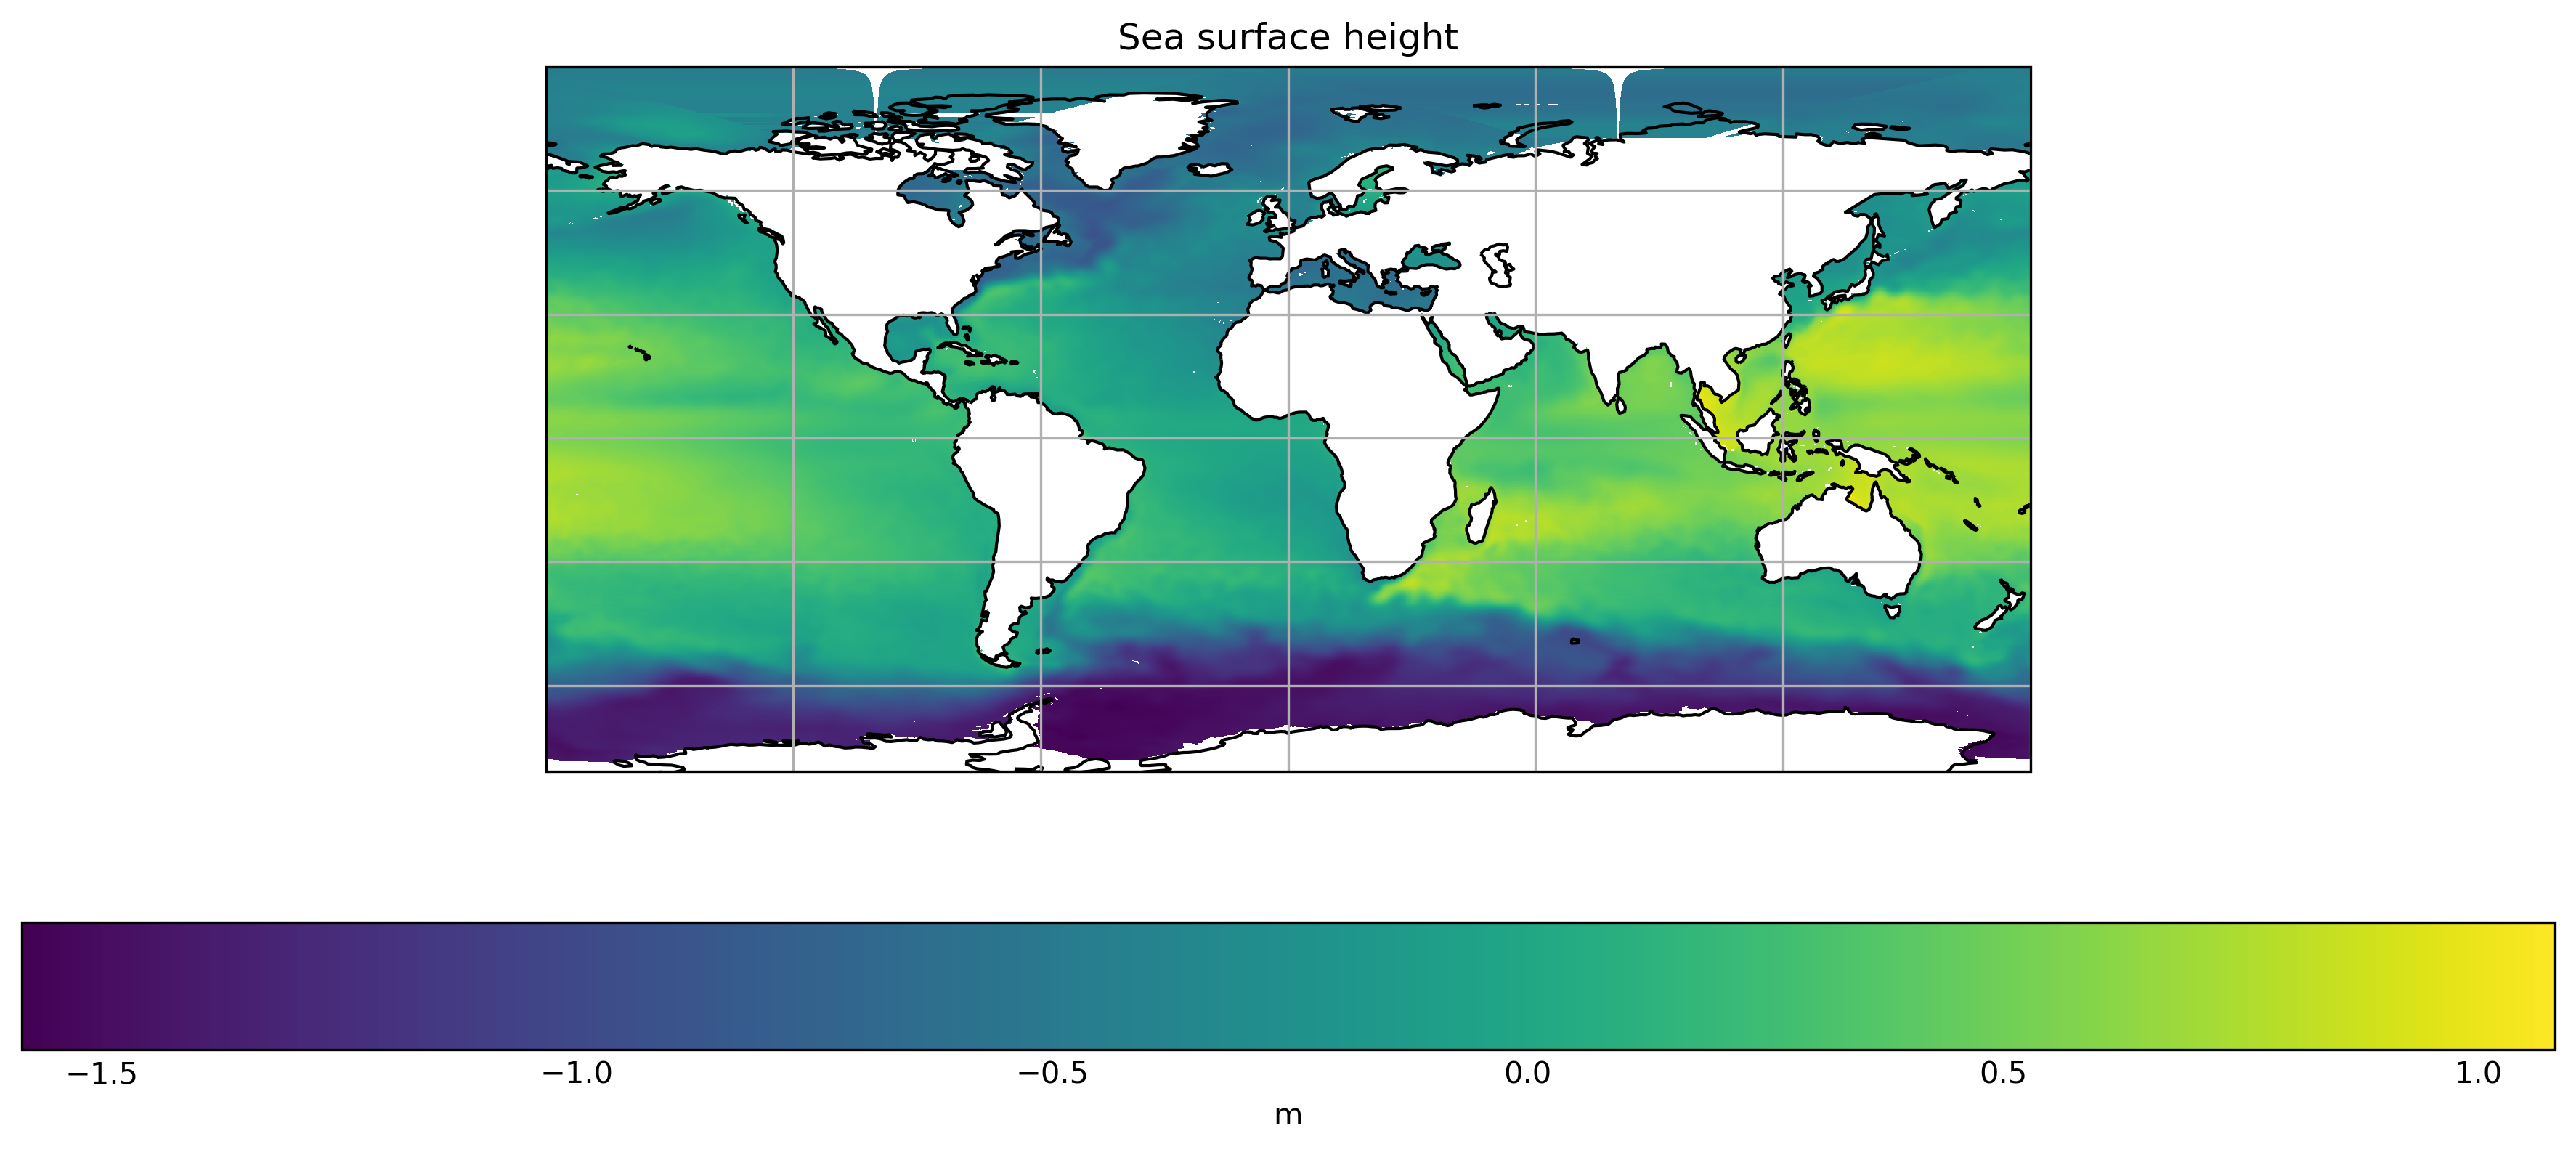

In [17]:
# regrid or map with aux coordinates?
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

# bounds of 2d coords added, plot by lon and lat
qplt.pcolormesh(cube[0], coords=['longitude','latitude'], axes=ax)
ax.coastlines()
_ = ax.gridlines()

Now try that plot again, this time using `.cf.assign_coords` to assign `geolon` and `geolat`.

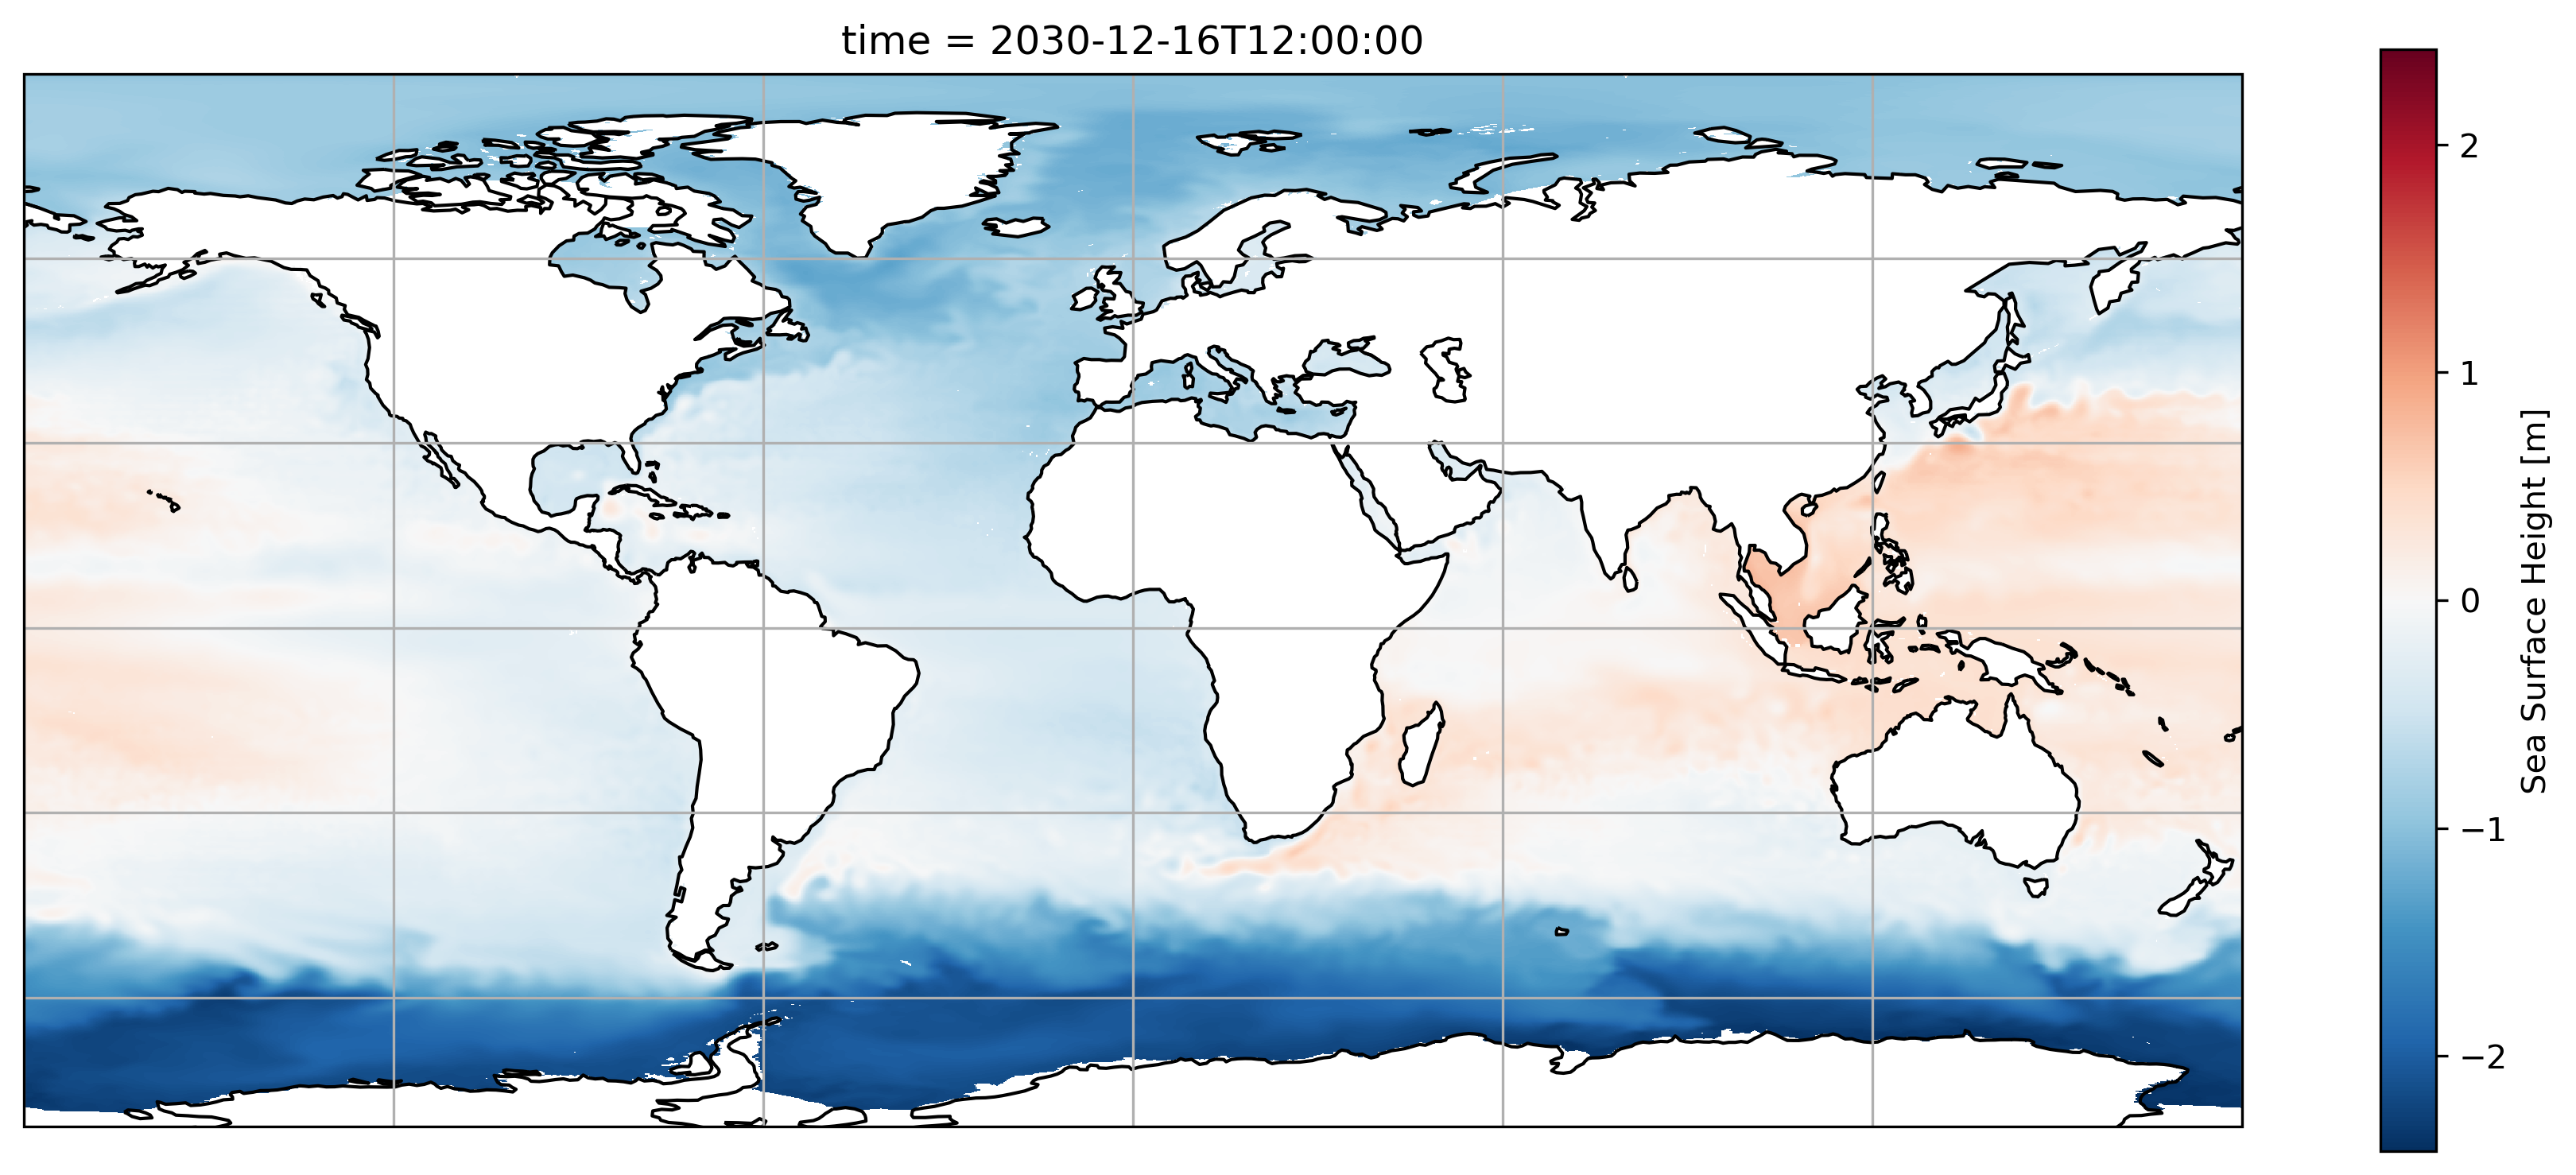

In [19]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

zos["SSH"].isel(time=-1).cf.assign_coords( { "longitude": static["geolon"],
                                              "latitude": static["geolat"] }).plot(ax=ax)
ax.coastlines()
_ = ax.gridlines()
# plt.savefig(plotfolder+'exampleout.png')

In [ ]:
# cube to enso recipes, add cell measure areacello - use for area statistics

In [36]:
from esmvalcore.preprocessor import anomalies
from esmvalcore.preprocessor import convert_units
from esmvalcore.preprocessor import extract_region
from esmvalcore.preprocessor import regrid
from esmvalcore.preprocessor import detrend
from esmvalcore.preprocessor import area_statistics

def ssh_east(cube):
    nino3_region = {"start_longitude": 210., "end_longitude": 270., "start_latitude": -5., "end_latitude": 5.}
    cube = convert_units(cube, units="cm")
    cube = extract_region(cube, **nino3_region)
    cube = anomalies(cube, period="monthly")
    # cube = detrend(cube, dimension="time", method="linear") #creates nan inf from masked array
    # cube = regrid(cube, target_grid="1x1", scheme="linear")
    # cube = area_statistics(cube,operator='mean') #requires supplementary variable

    return cube

In [18]:
cube[0].data

masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=1e+20,
  dtype=float32)

In [19]:

from esmvalcore.preprocessor import cmor_check_metadata
from esmvalcore.cmor._fixes.fix import GenericFix

var = GenericFix(get_var_info('CMIP6','Omon','zos'))
cube_fixed = var.fix_metadata(cubes=iris.cube.CubeList([cube]))[0]
# cmor_check_metadata(cube_fixed,'CMIP6','Omon','zos') #time.standard_name


(for variable zos)
(for variable zos)
(for variable zos)
(for variable zos)
(for variable zos)


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/iris/coords.py:2161: IrisVagueMetadataWarning: Collapsing a multi-dimensional coordinate. Metadata may not be fully descriptive for 'latitude'.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/iris/coords.py:2161: IrisVagueMetadataWarning: Collapsing a multi-dimensional coordinate. Metadata may not be fully descriptive for 'longitude'.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 50.93 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


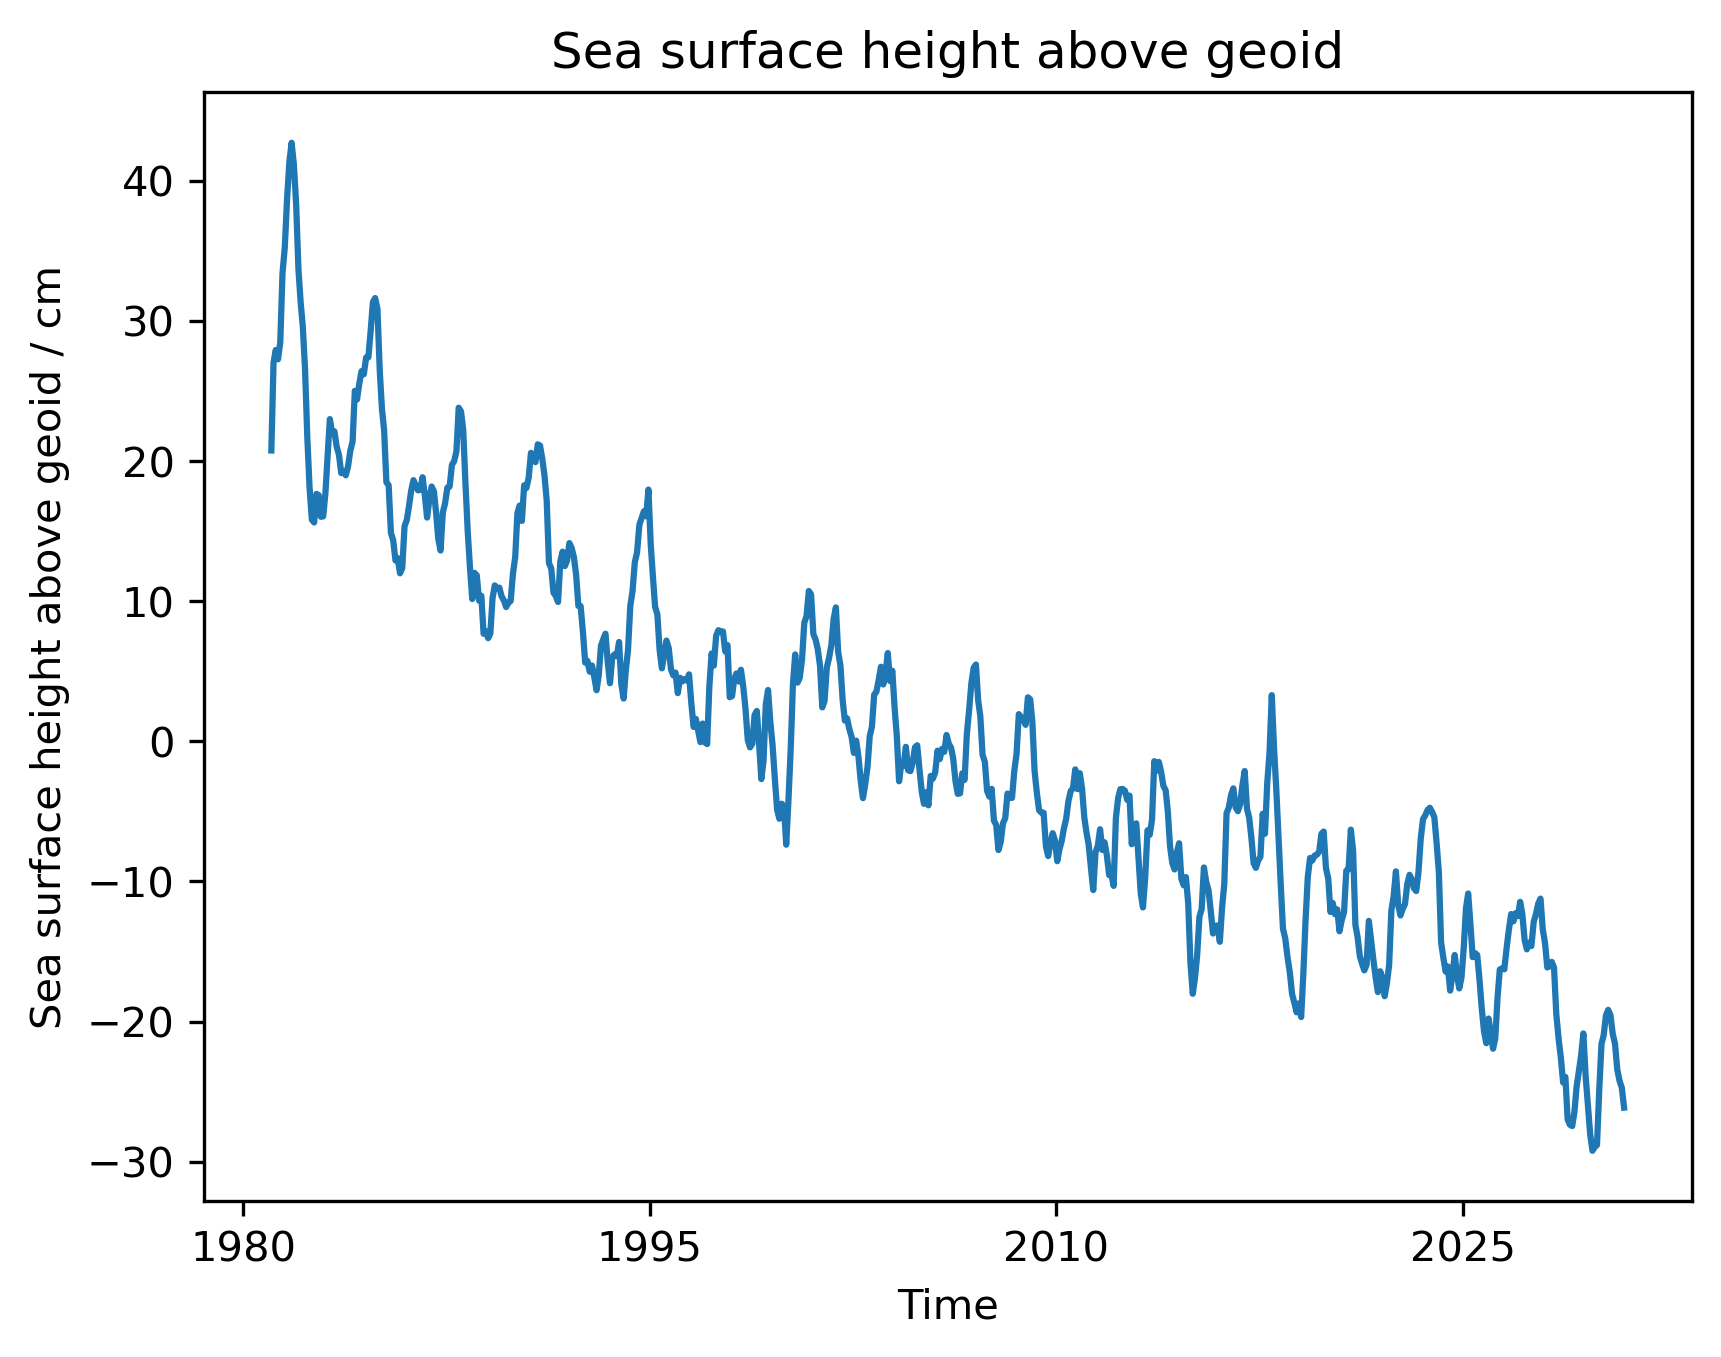

In [46]:
import dask.array as da
test = ssh_east(cube_fixed)

# instead of area_statistices using areacello weights
areastat = test.collapsed(['cell index along second dimension', 'cell index along first dimension'], 
               iris.analysis.MEAN, weights='areacello')
qplt.plot(areastat)


In [47]:
client.close()